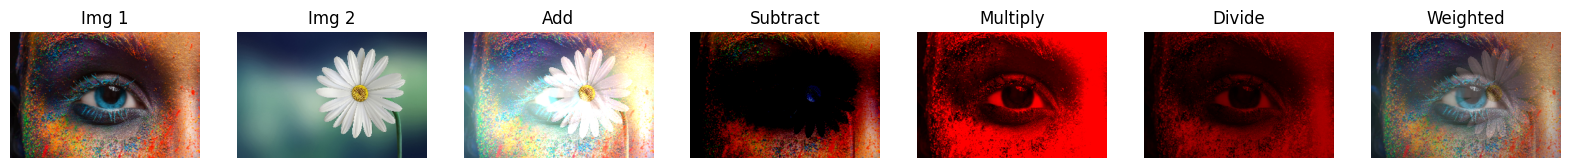

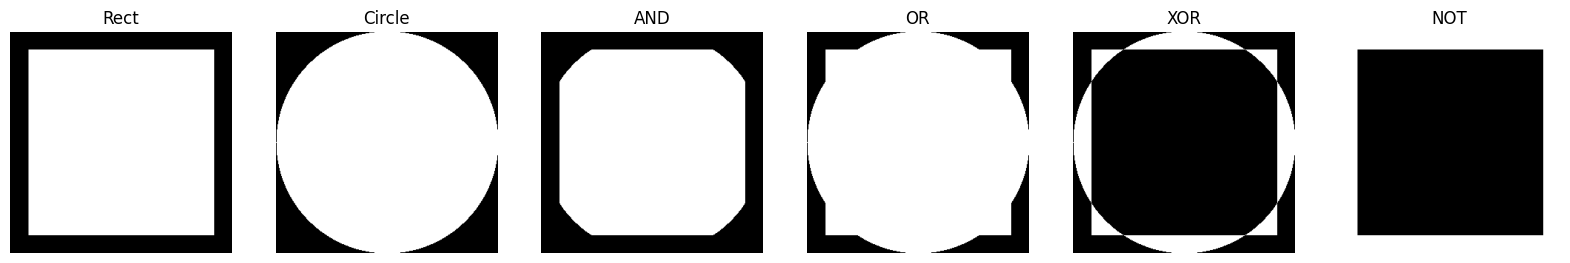

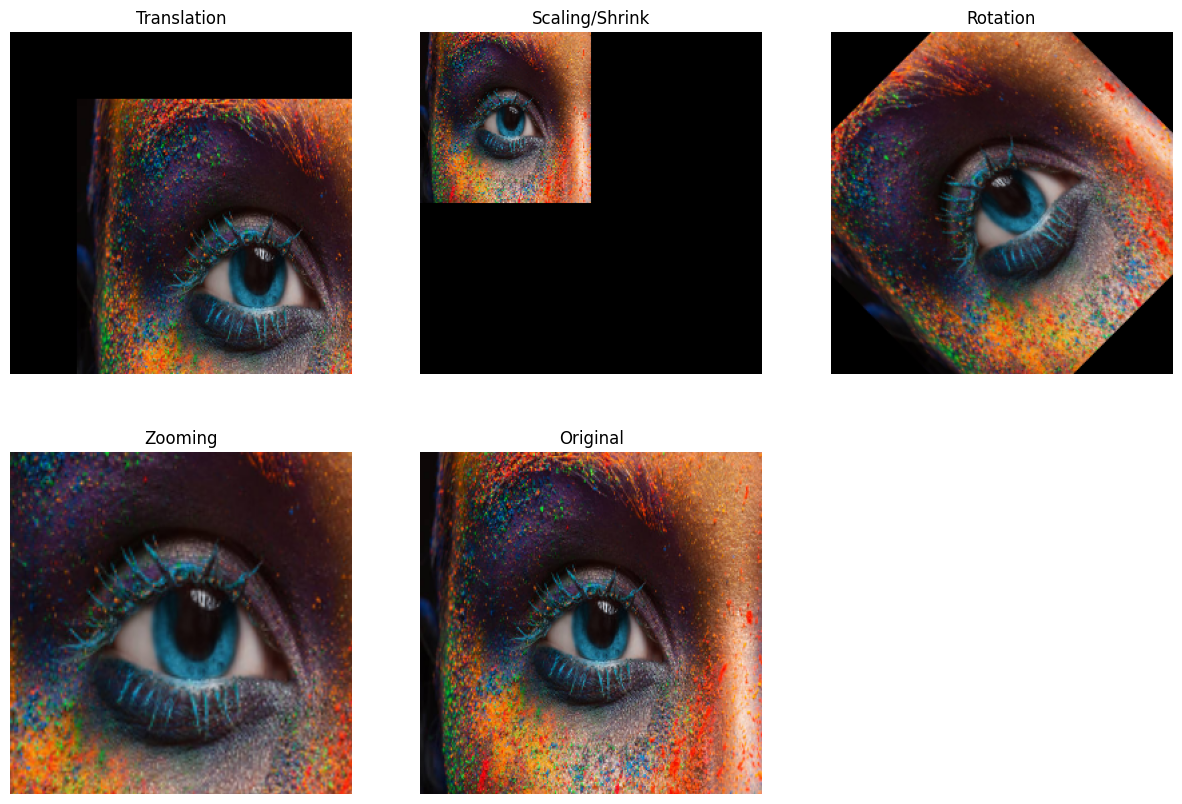

In [3]:
#Write a Python program to demonstrate various image processing operations including Arithmetic operations
#(Addition, Subtraction, Multiplication, Division),
#Bitwise operations (AND, OR, XOR, NOT), and Geometric transformations
#(Translation, Scaling, Rotation, Shrinking, Zooming) using OpenCV and Matplotlib.

import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PART 1: ARITHMETIC OPERATIONS ---
# Load two images
img1 = cv2.imread('image.jpg')
img2 = cv2.imread('image2.jpg')

if img1 is not None and img2 is not None:
    # Resize to same dimensions and convert to RGB for plotting
    img1_rgb = cv2.cvtColor(cv2.resize(img1, (300, 200)), cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(cv2.resize(img2, (300, 200)), cv2.COLOR_BGR2RGB)

    # Arithmetic math
    add_img = cv2.add(img1_rgb, img2_rgb)
    sub_img = cv2.subtract(img1_rgb, img2_rgb)
    mul_img = cv2.multiply(img1_rgb, np.array([1.5])) # Multiplied by scalar
    div_img = cv2.divide(img1_rgb, np.array([1.5]))   # Divided by scalar
    weighted = cv2.addWeighted(img1_rgb, 0.7, img2_rgb, 0.3, 0)

    # Plot Arithmetic Results
    titles = ['Img 1', 'Img 2', 'Add', 'Subtract', 'Multiply', 'Divide', 'Weighted']
    images = [img1_rgb, img2_rgb, add_img, sub_img, mul_img, div_img, weighted]

    plt.figure(figsize=(20, 5))
    for i in range(7):
        plt.subplot(1, 7, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# --- PART 2: BITWISE OPERATIONS ---
# Create synthetic shapes for clear logic demonstration
canvas_size = (300, 300)
rect = np.zeros(canvas_size, dtype="uint8")
cv2.rectangle(rect, (25, 25), (275, 275), 255, -1)

circ = np.zeros(canvas_size, dtype="uint8")
cv2.circle(circ, (150, 150), 150, 255, -1)

# Logic gates
b_and = cv2.bitwise_and(rect, circ)
b_or  = cv2.bitwise_or(rect, circ)
b_xor = cv2.bitwise_xor(rect, circ)
b_not = cv2.bitwise_not(rect)

# Plot Bitwise Results

titles_bw = ['Rect', 'Circle', 'AND', 'OR', 'XOR', 'NOT']
images_bw = [rect, circ, b_and, b_or, b_xor, b_not]

plt.figure(figsize=(20, 5))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images_bw[i], cmap='gray')
    plt.title(titles_bw[i])
    plt.axis('off')
plt.show()

# --- PART 3: GEOMETRIC TRANSFORMATIONS ---
# Resize original for consistent transformation results
base_img = cv2.resize(img1, (256, 256))
rows, cols = base_img.shape[:2]

# (a) Translation (Shift right 50, down 50)
M_trans = np.float32([[1, 0, 50], [0, 1, 50]])
trans_img = cv2.warpAffine(base_img, M_trans, (cols, rows))

# (b) Scaling / (d) Shrinking (0.5x)
M_scale = np.float32([[0.5, 0, 0], [0, 0.5, 0]])
scale_img = cv2.warpAffine(base_img, M_scale, (cols, rows))

# (c) Rotation (45 degrees around center)
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
rot_img = cv2.warpAffine(base_img, M_rot, (cols, rows))

# (e) Zooming (1.5x)
M_zoom = np.float32([[1.5, 0, -64], [0, 1.5, -64]]) # Shifted to keep center
zoom_img = cv2.warpAffine(base_img, M_zoom, (cols, rows))

# Plot Geometric Results

titles_geo = ['Translation', 'Scaling/Shrink', 'Rotation', 'Zooming', 'Original']
images_geo = [trans_img, scale_img, rot_img, zoom_img, base_img]

plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i + 1)
    # Convert BGR to RGB for correct colors in Matplotlib
    plt.imshow(images_geo[i][:,:,::-1])
    plt.title(titles_geo[i])
    plt.axis('off')
plt.show()